In [48]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [49]:
df = pd.read_csv("benchmark_result.csv")
df.head()

,threads,increments_per_thread,mutex_ms,mutex_eb_ms,cas_ms,cas_eb_ms,fetch_add_ms
0,1,100000,1.4426,1.2271,1.3170,1.1341,0.6582
1,2,100000,6.0422,16.4010,9.7184,10.5097,2.8339
2,4,100000,9.8206,74.0522,31.9014,44.6386,5.7606
3,8,100000,30.8565,272.5000,81.1071,113.4050,13.4886
4,12,100000,72.8714,693.2940,177.3740,207.3700,24.5336


In [50]:
grouped_means = df.groupby('threads')[['mutex_ms', 'mutex_eb_ms', 'cas_ms', 'cas_eb_ms', 'fetch_add_ms']].mean().reset_index()
grouped_means

,threads,mutex_ms,mutex_eb_ms,cas_ms,cas_eb_ms,fetch_add_ms
0,1,3.347670,3.405205,2.418415,2.509090,1.535275
1,2,8.878920,23.774025,17.384955,11.932195,5.565135
2,4,12.743110,101.631695,45.193305,49.946880,9.740985
3,8,39.858305,432.859150,139.567305,158.854100,23.411030
4,12,76.371125,1071.980750,322.094450,345.584150,39.889075
5,16,118.167995,1936.201500,575.386900,616.754250,59.037690
6,20,148.731650,2589.665500,763.951750,758.657800,72.806920


In [51]:
# # Calculate throughput in increments per millisecond for each method and add to a new DataFrame
# methods = ['mutex_ms', 'mutex_eb_ms', 'cas_ms', 'cas_eb_ms', 'fetch_add_ms']
# throughput_df = grouped_means[['threads']].copy()
# operations_per_thread = df['increments_per_thread'].iloc[0]

# for method in methods:
#     # Throughput = (increments_per_thread * threads) / time (ms)
#     throughput_df[method.replace('_ms', '_throughput')] = \
#         (operations_per_thread * grouped_means['threads']) / grouped_means[method]

# throughput_df

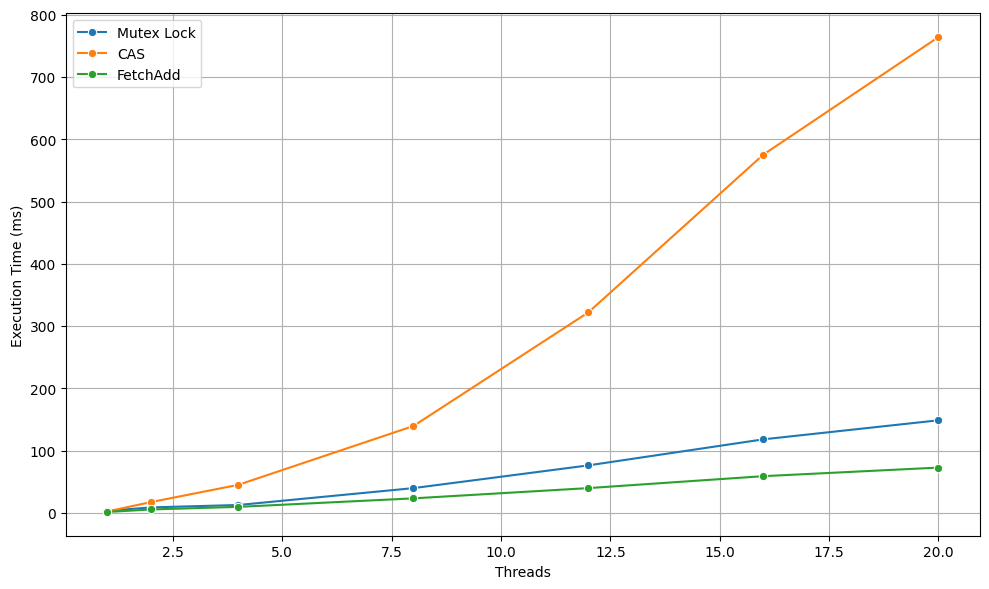

In [52]:
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=grouped_means,
    x='threads',
    y='mutex_ms',
    marker='o',
    label='Mutex Lock'
)
sns.lineplot(
    data=grouped_means,
    x='threads',
    y='cas_ms',
    marker='o',
    label='CAS'
)
sns.lineplot(
    data=grouped_means,
    x='threads',
    y='fetch_add_ms',
    marker='o',
    label='FetchAdd'
)

plt.xlabel("Threads")
plt.ylabel("Execution Time (ms)")
# plt.title("Counter Performance vs Threads")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

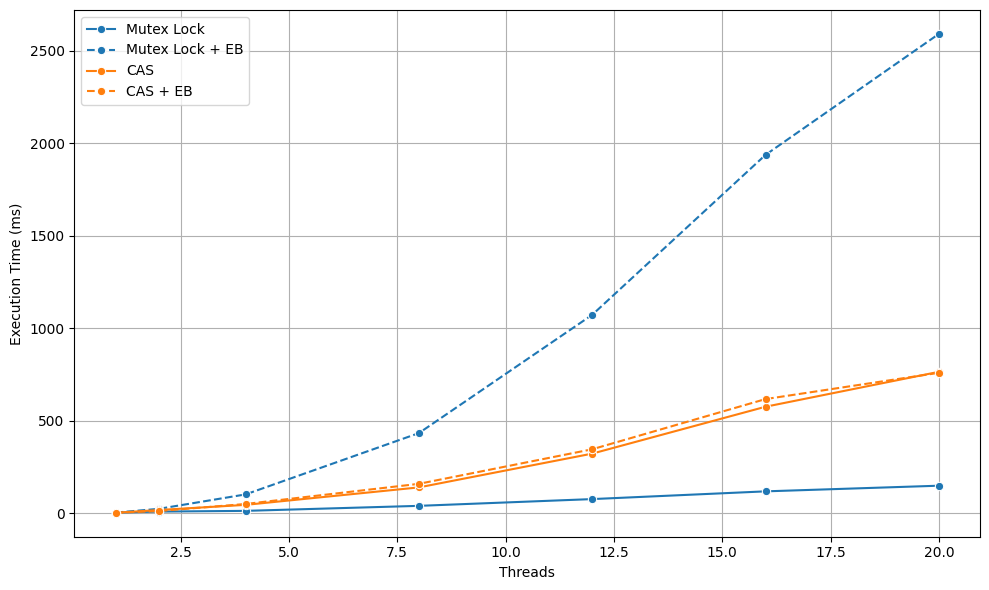

In [53]:
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=grouped_means,
    x='threads',
    y='mutex_ms',
    marker='o',
    label='Mutex Lock'
)
sns.lineplot(
    data=grouped_means,
    x='threads',
    y='mutex_eb_ms',
    marker='o',
    label='Mutex Lock + EB',
    linestyle='--',
    color=sns.color_palette()[0]
)

sns.lineplot(
    data=grouped_means,
    x='threads',
    y='cas_ms',
    marker='o',
    label='CAS'
)
sns.lineplot(
    data=grouped_means,
    x='threads',
    y='cas_eb_ms',
    marker='o',
    label='CAS + EB',
    linestyle='--',
    color=sns.color_palette()[1]
)

plt.xlabel("Threads")
plt.ylabel("Execution Time (ms)")
# plt.title("Counter Performance vs Threads")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()